# Otimizando a Experiência do Cliente no E-commerce Brasileiro: 
## Uma Análise de 100 mil Pedidos

# 📈 Objetivos do Projeto

Nesta análise, exploraremos o ecossistema da **Olist** para responder a perguntas críticas de negócio divididas em cinco pilares estratégicos.

---

### 1. Visão Geral de Vendas (O "Coração" do Negócio)
*Essas perguntas ajudam a entender a saúde financeira da empresa.*

* **Crescimento Mensal:** Qual é a evolução do faturamento total (GMV) e do volume de pedidos mês a mês? Existe sazonalidade?
* **Ticket Médio:** Qual o valor médio gasto por pedido? Esse valor varia por categoria de produto ou por estado?
* **Meios de Pagamento:** Qual a preferência de pagamento dos brasileiros (cartão, boleto, voucher)? O número de parcelas afeta o valor total da compra?

### 2. Análise de Logística (Eficiência Operacional)
*O frete no Brasil é um desafio logístico. Analisar esses dados demonstra maturidade analítica sobre o mercado nacional.*

* **Prometido vs. Entregue:** Qual a porcentagem de pedidos entregues dentro do prazo?
* **Custo de Frete:** Qual o peso do frete no valor total da compra? Existem estados onde o frete elevado desestimula vendas?
* **Tempo de Entrega:** Qual a média de dias para entrega por região?

### 3. Comportamento do Cliente e Produto
* **Concentração Geográfica:** Onde estão os clientes mais valiosos (Cidades/Estados)?
* **Categorias Populares:** Quais categorias trazem mais receita e quais trazem mais volume de vendas?
* **Fidelidade:** Existe recompra nesse dataset? Quantos clientes compraram mais de uma vez?

### 4. Experiência do Usuário (NPS e Reviews)
* **Satisfação:** Qual a correlação entre o tempo de atraso na entrega e a nota (score) dada pelo cliente?
* **Principais Reclamações:** Quais são as categorias de produtos com as piores avaliações?

### 5. Análise RFM (Segmentação Estratégica)
*Identificação dos melhores clientes através da técnica **RFM**:*

> **Recência (R):** Há quanto tempo foi a última compra.  
> **Frequência (F):** Quantas vezes o cliente comprou.  
> **Valor Monetário (M):** Quanto o cliente gastou no total.

---


#### Importando as Bibiliotecas necessárias

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker # Importante para a formatação


from src.config import DADOS_TRATADO, geolocation
from src.graficos import composicao_histograma_boxplot

sns.set_theme(palette="bright")

# Define o limite máximo de colunas exibidas para 500
pd.set_option('display.max_columns', 100)

#### Importação dos dados e análise da tabela

In [2]:
df = pd.read_parquet(DADOS_TRATADO)

df.head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40,268,4,500,19,8,13,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29,178,1,400,19,13,19,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46,232,1,420,24,19,21,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59,468,3,450,30,10,20,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38,316,4,250,51,15,15,8752,mogi das cruzes,SP


#### Verificando tipos de dados e valores não nulos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108636 entries, 0 to 108635
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       108636 non-null  string        
 1   customer_id                    108636 non-null  string        
 2   order_purchase_timestamp       108636 non-null  datetime64[ns]
 3   order_approved_at              108636 non-null  datetime64[ns]
 4   order_delivered_carrier_date   108636 non-null  datetime64[ns]
 5   order_delivered_customer_date  108636 non-null  datetime64[ns]
 6   order_estimated_delivery_date  108636 non-null  datetime64[ns]
 7   customer_unique_id             108636 non-null  string        
 8   customer_zip_code_prefix       108636 non-null  string        
 9   customer_city                  108636 non-null  string        
 10  customer_state                 108636 non-null  string        
 11  

In [4]:
df.nunique()

order_id                         95123
customer_id                      95123
order_purchase_timestamp         94619
order_approved_at                87119
order_delivered_carrier_date     78915
order_delivered_customer_date    94335
order_estimated_delivery_date      445
customer_unique_id               92076
customer_zip_code_prefix         14844
customer_city                     4073
customer_state                      27
order_item_id                       21
product_id                       31625
seller_id                         2914
shipping_limit_date              90122
price                             5792
freight_value                     6902
product_category_name               73
product_name_lenght                 65
product_description_lenght        2944
product_photos_qty                  19
product_weight_g                  2169
product_length_cm                   99
product_height_cm                  102
product_width_cm                    94
seller_zip_code_prefix   

In [5]:
df.isnull().sum()

order_id                         0
customer_id                      0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
seller_zip_code_prefix           0
seller_city                      0
seller_state                     0
dtype: int64

In [6]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,108636,108636,108636,108636,108636,108636.000000,108636,108636.000000,108636.000000,108636.000000,108636.000000,108636.000000,108636.000000,108636.000000,108636.000000,108636.000000
mean,2018-01-02 21:50:36.048409344,2018-01-03 08:22:11.120006144,2018-01-06 04:30:37.983090432,2018-01-15 09:03:27.604026112,2018-01-26 17:11:56.977797632,1.198636,2018-01-09 12:20:33.938059264,120.087161,19.982936,48.808351,787.327175,2.210833,2095.634725,30.198258,16.588102,23.030699
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000,2016-09-19 23:11:33,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,2017-09-16 01:19:37.500000,2017-09-16 12:54:01.249999872,2017-09-19 17:52:26,2017-09-27 18:36:18.500000,2017-10-06 00:00:00,1.000000,2017-09-21 23:20:37.249999872,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,2018-01-22 11:55:48,2018-01-22 20:04:44,2018-01-25 15:18:01,2018-02-05 14:28:48,2018-02-19 00:00:00,1.000000,2018-01-29 13:52:42,74.900000,16.290000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,2018-05-06 18:15:02.249999872,2018-05-07 16:53:05,2018-05-09 10:00:30,2018-05-16 16:08:58,2018-05-28 00:00:00,1.000000,2018-05-11 16:31:29,134.900000,21.160000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000
std,NaN,NaN,NaN,NaN,NaN,0.708558,NaN,182.044245,15.733818,10.007970,651.363932,1.721833,3744.124300,16.157552,13.433047,11.697217


In [7]:
df.describe(exclude=['number','datetime'])

,order_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,product_category_name,seller_zip_code_prefix,seller_city,seller_state
count,108636,108636,108636,108636,108636,108636,108636,108636,108636,108636,108636,108636
unique,95123,95123,92076,14844,4073,27,31625,2914,73,2136,588,22
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,c8460e4251689ba205045f3ea17884a1,22790,sao paulo,SP,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,cama_mesa_banho,14940,sao paulo,SP
freq,21,21,24,145,17117,45812,520,1996,10952,7600,27155,77482


#### Exploração Univariada

##### Datas

In [11]:
df['order_purchase_timestamp'].dt.date.value_counts().sort_index().head(20)

order_purchase_timestamp
2016-09-15     3
2016-10-03     7
2016-10-04    62
2016-10-05    48
2016-10-06    47
2016-10-07    44
2016-10-08    40
2016-10-09    26
2016-10-10    37
2016-12-23     1
2017-01-05    32
2017-01-06     4
2017-01-07     5
2017-01-08     4
2017-01-09     6
2017-01-10     6
2017-01-11    10
2017-01-12    14
2017-01-13    10
2017-01-14    16
Name: count, dtype: int64

<Axes: >

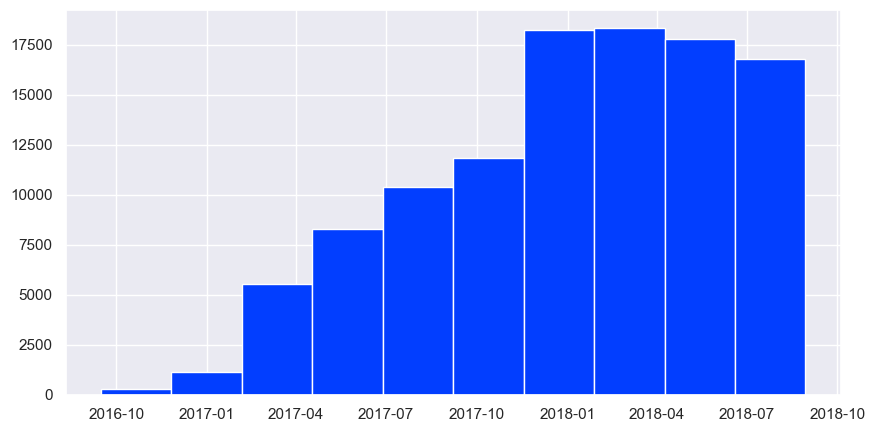

In [9]:
df['order_purchase_timestamp'].hist(figsize=(10,5))

In [12]:
df['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()

order_purchase_timestamp
2016-09       3
2016-10     311
2016-12       1
2017-01     898
2017-02    1790
2017-03    2837
2017-04    2500
2017-05    3912
2017-06    3431
2017-07    4358
2017-08    4722
2017-09    4663
2017-10    5146
2017-11    8356
2017-12    6050
2018-01    7844
2018-02    7401
2018-03    7884
2018-04    7753
2018-05    7768
2018-06    6984
2018-07    6913
2018-08    7111
Freq: M, Name: count, dtype: int64

In [33]:
df['Anomes_purchase'] = df['order_purchase_timestamp'].dt.to_period('M')

In [36]:
df['Anomes_purchase'].value_counts().sort_index()

Anomes_purchase
2016-09       3
2016-10     311
2016-12       1
2017-01     898
2017-02    1790
2017-03    2837
2017-04    2500
2017-05    3912
2017-06    3431
2017-07    4358
2017-08    4722
2017-09    4663
2017-10    5146
2017-11    8356
2017-12    6050
2018-01    7844
2018-02    7401
2018-03    7884
2018-04    7753
2018-05    7768
2018-06    6984
2018-07    6913
2018-08    7111
Freq: M, Name: count, dtype: int64

In [15]:
df[df['order_purchase_timestamp'].dt.to_period('Y') == '2016'].head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
410,cbbb524a0e1646aa6cf7a3c0bbe517ad,dacb079d55ffb1d3955c5d923df3ebb7,2016-10-05 07:31:49,2016-10-06 02:46:24,2016-10-10 02:46:24,2016-10-16 14:36:00,2016-12-07,12cc890391e57d7123e004856ff1f137,50090,recife,PE,1,bab7ff9abbcc13690a62d015f2ca8e44,229c3efbfb0ea2058de4ccdfbc3d784a,2016-10-10 02:46:24,75.0,20.58,informatica_acessorios,43,269,1,250,30,7,20,30190,belo horizonte,MG
775,ac2b7c522d811acba0aa270ed3e112e4,ef21aebbb093a6db29ccc6aa0b89c347,2016-10-05 15:08:00,2016-10-06 15:44:26,2016-10-10 15:44:27,2016-10-13 15:44:27,2016-11-29,664f7107c351f24b16b68919398730a0,13610,leme,SP,1,4632bc49b300378ed4f1d48f424d414e,ed859002ad59dbf8cf3602696a6c3000,2016-10-10 15:44:27,294.9,20.34,automotivo,33,513,2,795,30,15,26,86035,londrina,PR
1533,7033745709b7cf1bac7d2533663592de,7f0ca17bb33b230b47459437cf0682c7,2016-10-04 14:13:22,2016-10-04 14:46:48,2016-10-08 14:46:49,2016-10-11 14:46:49,2016-11-30,1dc848c11c2985635c268ff3dea707eb,21853,rio de janeiro,RJ,1,35084deab9603bbb6035bb8638b1df89,df560393f3a51e74553ab94004ba5c87,2016-10-08 14:46:49,93.9,17.61,moveis_decoracao,49,100,1,1200,25,25,20,87900,loanda,PR
1607,5cd498954e2b37d71b315166809b4bd7,ff1a56726b7ea149c7423865609cc0c8,2016-10-07 00:54:40,2016-10-08 03:56:15,2016-10-25 11:35:52,2016-10-27 17:32:07,2016-12-01,fb48b86d9a78b53675c121e4ec8981ed,21220,rio de janeiro,RJ,1,896a64a7f34cdfef2c60ce59fa2a148f,82bd0703a4aefd6b599e5bfdaed378fb,2016-10-12 03:56:16,44.9,15.63,perfumaria,50,899,3,800,38,13,22,17510,marilia,SP
1608,5cd498954e2b37d71b315166809b4bd7,ff1a56726b7ea149c7423865609cc0c8,2016-10-07 00:54:40,2016-10-08 03:56:15,2016-10-25 11:35:52,2016-10-27 17:32:07,2016-12-01,fb48b86d9a78b53675c121e4ec8981ed,21220,rio de janeiro,RJ,2,896a64a7f34cdfef2c60ce59fa2a148f,82bd0703a4aefd6b599e5bfdaed378fb,2016-10-12 03:56:16,44.9,15.63,perfumaria,50,899,3,800,38,13,22,17510,marilia,SP


<Axes: >

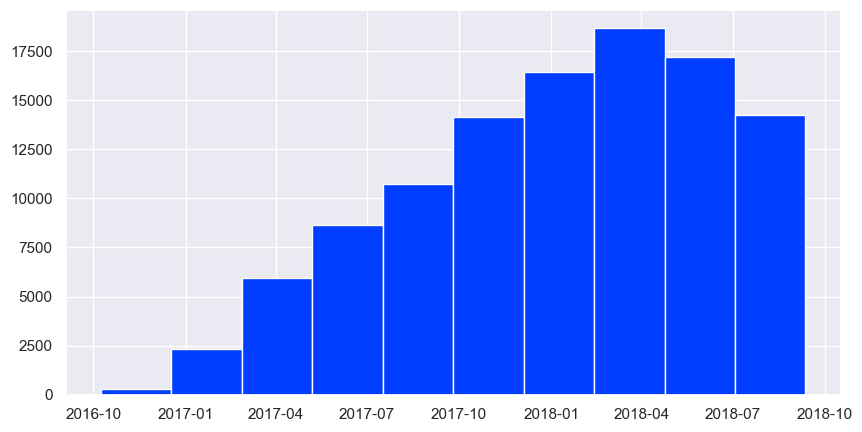

In [16]:
df['order_delivered_carrier_date'].hist(figsize=(10,5))

<Axes: >

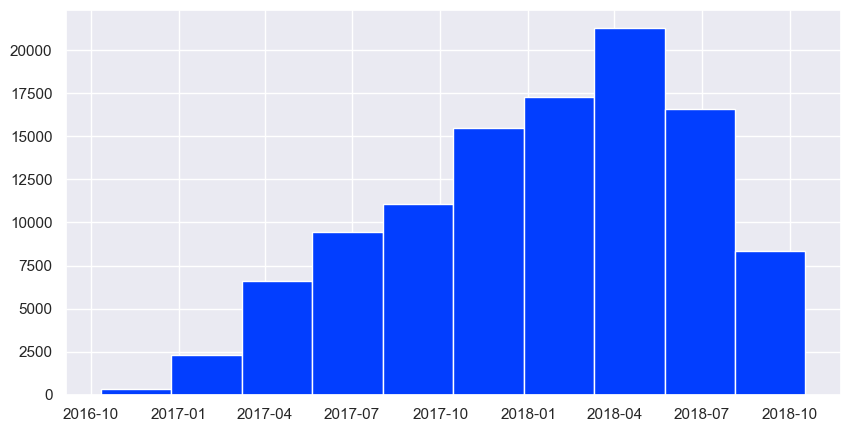

In [17]:
df['order_delivered_customer_date'].hist(figsize=(10,5))

<Axes: >

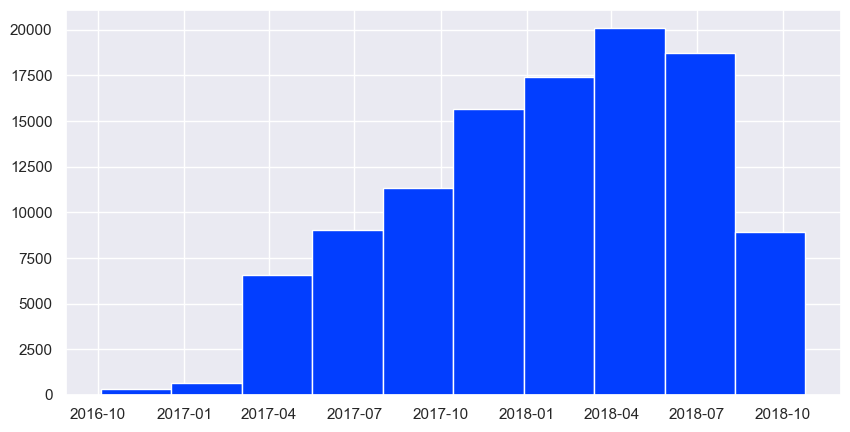

In [18]:
df['order_estimated_delivery_date'].hist(figsize=(10,5))

<Axes: >

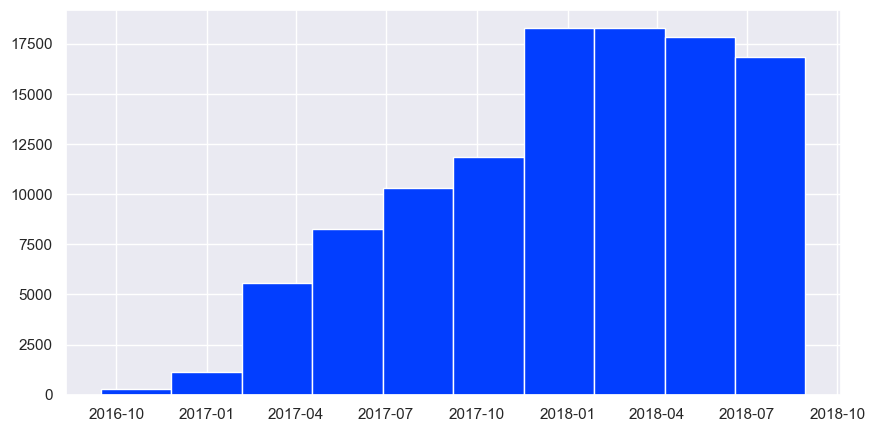

In [19]:
df['order_approved_at'].hist(figsize=(10,5))

<Axes: >

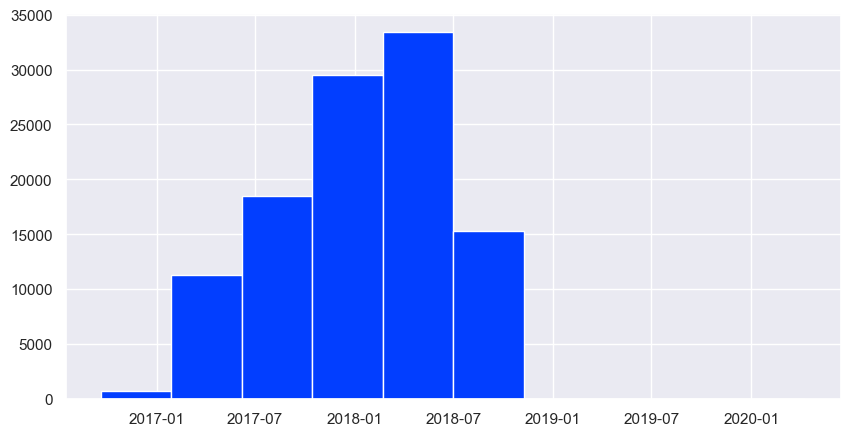

In [84]:
df['shipping_limit_date'].hist(figsize=(10,5))

##### IDs

In [20]:
df['order_id'].value_counts()[:5]

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
ab14fdcfbe524636d65ee38360e22ce8    20
1b15974a0141d54e36626dca3fdc731a    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
Name: count, dtype: Int64

In [21]:
df['customer_id'].value_counts()[:5]

customer_id
fc3d1daec319d62d49bfb5e1f83123e9    21
bd5d39761aa56689a265d95d8d32b8be    20
be1b70680b9f9694d8c70f41fa3dc92b    20
adb32467ecc74b53576d9d13a5a55891    15
10de381f8a8d23fff822753305f71cae    15
Name: count, dtype: Int64

In [22]:
df['customer_unique_id'].value_counts()[:5]

customer_unique_id
c8460e4251689ba205045f3ea17884a1    24
4546caea018ad8c692964e3382debd19    21
698e1cf81d01a3d389d96145f7fa6df8    20
c402f431464c72e27330a67f7b94d4fb    20
0f5ac8d5c31de21d2f25e24be15bbffb    18
Name: count, dtype: Int64

In [23]:
df['order_item_id'].value_counts() 

order_item_id
1     95096
2      9504
3      2214
4       927
5       436
6       247
7        58
8        35
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: count, dtype: int64

Temos 94.831 compras distintas, e uma delas teve 21 itens comprados de uma só vez

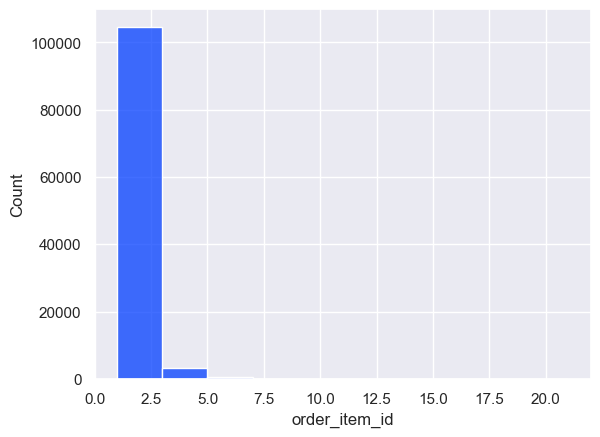

In [24]:
sns.histplot(data = df, x = 'order_item_id', bins=10);

In [25]:
df['product_id'].value_counts()[:5]

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    520
422879e10f46682990de24d770e7f83d    484
99a4788cb24856965c36a24e339b6058    477
389d119b48cf3043d311335e499d9c6b    390
368c6c730842d78016ad823897a372db    388
Name: count, dtype: Int64

In [26]:
df['seller_id'].value_counts()[:5]

seller_id
6560211a19b47992c3666cc44a7e94c0    1996
4a3ca9315b744ce9f8e9374361493884    1949
1f50f920176fa81dab994f9023523100    1926
cc419e0650a3c5ba77189a1882b7556a    1719
da8622b14eb17ae2831f4ac5b9dab84a    1548
Name: count, dtype: Int64

##### Variáveis Numéricas

In [27]:
df['price'].describe()

count    108636.000000
mean        120.087161
std         182.044245
min           0.850000
25%          39.900000
50%          74.900000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

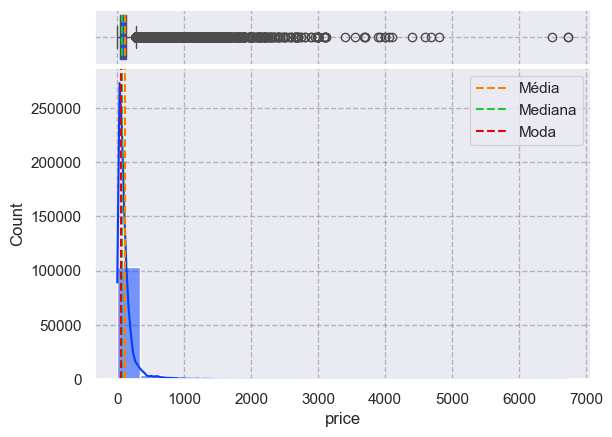

In [48]:
composicao_histograma_boxplot(dataframe=df, coluna='price', intervalos=20)

In [29]:
df['freight_value'].describe()

count    108636.000000
mean         19.982936
std          15.733818
min           0.000000
25%          13.080000
50%          16.290000
75%          21.160000
max         409.680000
Name: freight_value, dtype: float64

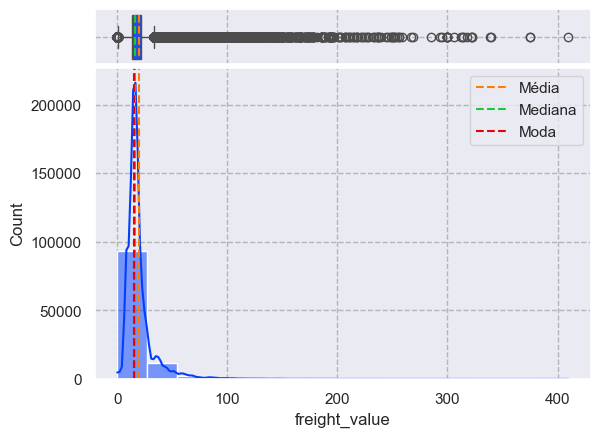

In [45]:
composicao_histograma_boxplot(dataframe=df, coluna='freight_value', intervalos=15)

In [37]:
df['product_length_cm'].describe()

count    108636.000000
mean         30.198258
std          16.157552
min           7.000000
25%          18.000000
50%          25.000000
75%          38.000000
max         105.000000
Name: product_length_cm, dtype: float64

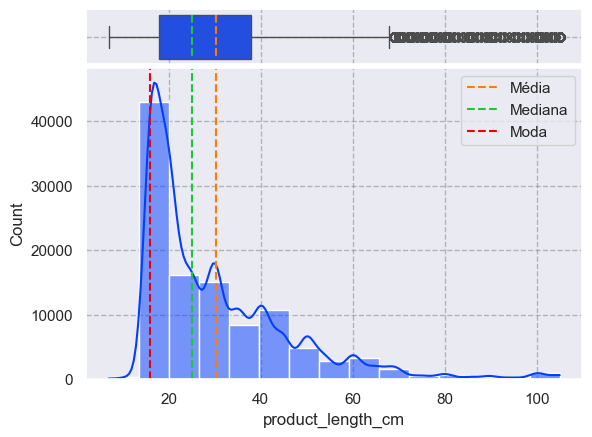

In [43]:
composicao_histograma_boxplot(dataframe=df, coluna='product_length_cm', intervalos=15)

In [40]:
df['product_height_cm'].describe()

count    108636.000000
mean         16.588102
std          13.433047
min           2.000000
25%           8.000000
50%          13.000000
75%          20.000000
max         105.000000
Name: product_height_cm, dtype: float64

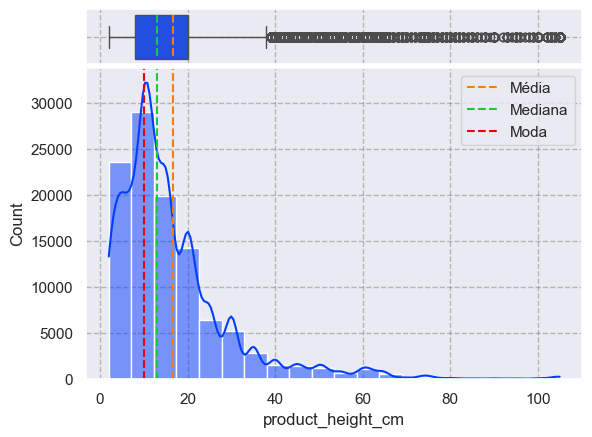

In [44]:
composicao_histograma_boxplot(dataframe=df, coluna='product_height_cm', intervalos=20)

In [49]:
df['product_weight_g'].describe()

count    108636.000000
mean       2095.634725
std        3744.124300
min           0.000000
25%         300.000000
50%         700.000000
75%        1800.000000
max       40425.000000
Name: product_weight_g, dtype: float64

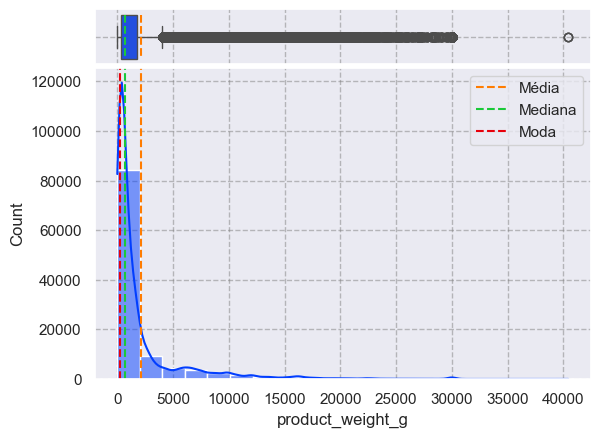

In [62]:
composicao_histograma_boxplot(dataframe=df, coluna='product_weight_g', intervalos=20)

In [51]:
df['product_photos_qty'].describe()

count    108636.000000
mean          2.210833
std           1.721833
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max          20.000000
Name: product_photos_qty, dtype: float64

<Axes: xlabel='product_photos_qty', ylabel='count'>

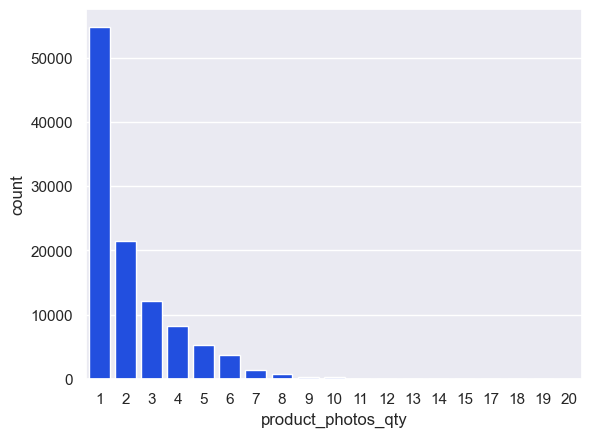

In [60]:
sns.countplot(data=df, x ='product_photos_qty')

In [63]:
df['product_width_cm'].describe()

count    108636.000000
mean         23.030699
std          11.697217
min           6.000000
25%          15.000000
50%          20.000000
75%          30.000000
max         118.000000
Name: product_width_cm, dtype: float64

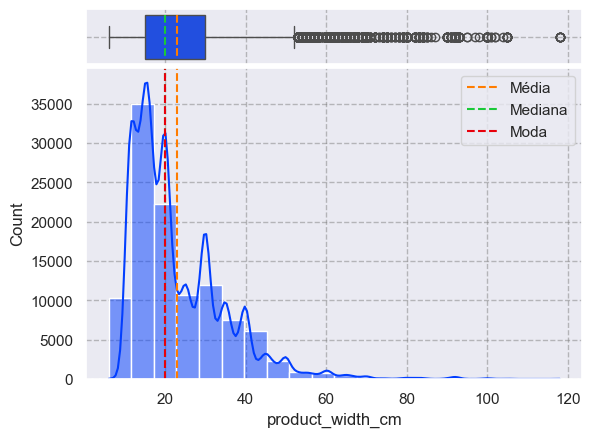

In [64]:
composicao_histograma_boxplot(dataframe=df, coluna='product_width_cm', intervalos=20)

##### Variáveis categóricas

In [ ]:
customer_city

In [70]:
df['customer_city'].value_counts()[:8]

customer_city 
sao paulo         17117
rio de janeiro     7470
belo horizonte     3033
brasilia           2310
curitiba           1710
campinas           1605
porto alegre       1547
salvador           1332
Name: count, dtype: int64

<Axes: xlabel='customer_city'>

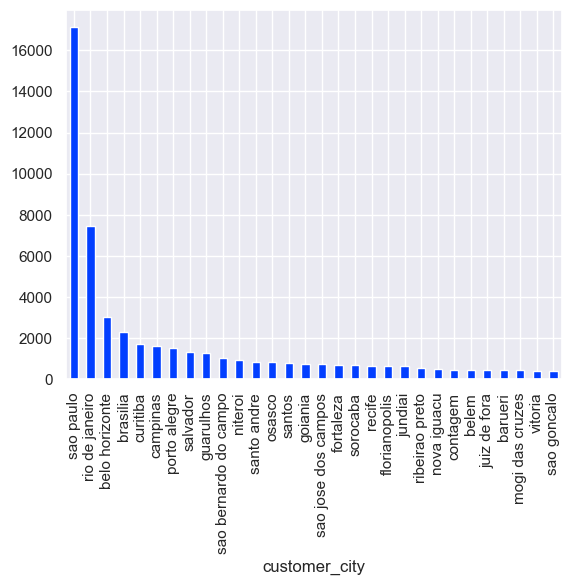

In [76]:
df['customer_city'].value_counts()[:30].plot(kind='bar')

In [77]:
df['customer_state'].value_counts()

customer_state
SP    45812
RJ    13928
MG    12734
RS     6036
PR     5572
SC     4037
BA     3625
DF     2323
GO     2225
ES     2207
PE     1723
CE     1409
PA     1036
MT     1025
MS      802
MA      790
PB      577
PI      516
RN      515
AL      423
SE      373
TO      306
RO      267
AM      161
AC       89
AP       81
RR       44
Name: count, dtype: Int64

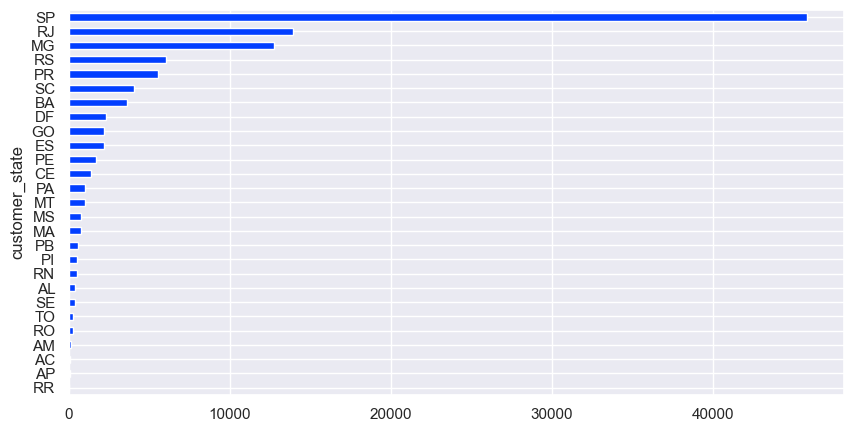

In [83]:
df['customer_state'].value_counts(ascending=True).plot(kind='barh', figsize=(10,5));

In [90]:
df['product_category_name'].value_counts()[:10]

product_category_name
cama_mesa_banho           10952
beleza_saude               9465
esporte_lazer              8428
moveis_decoracao           8156
informatica_acessorios     7643
utilidades_domesticas      6795
relogios_presentes         5857
telefonia                  4428
ferramentas_jardim         4267
automotivo                 4139
Name: count, dtype: int64

<Axes: ylabel='product_category_name'>

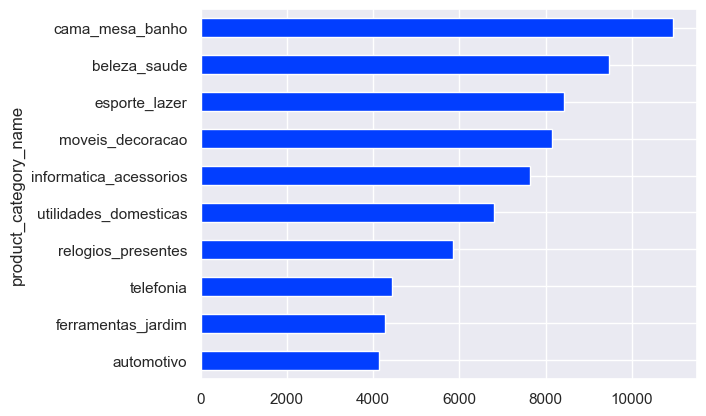

In [95]:
df['product_category_name'].value_counts(ascending=True)[-10:].plot(kind='barh')

In [96]:
df['seller_city'].value_counts()[:8]

seller_city
sao paulo                27155
ibitinga                  7600
curitiba                  2926
santo andre               2884
sao jose do rio preto     2538
belo horizonte            2444
rio de janeiro            2292
maringa                   2192
Name: count, dtype: Int64

<Axes: xlabel='seller_city'>

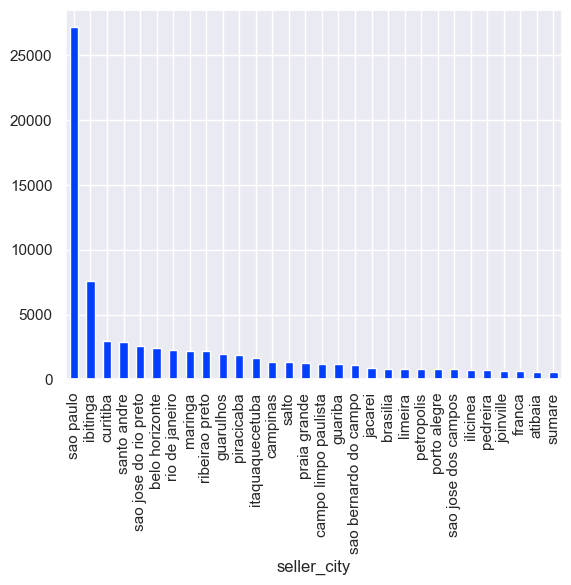

In [97]:
df['seller_city'].value_counts()[:30].plot(kind='bar')

In [99]:
df['seller_state'].value_counts()

seller_state
SP    77482
PR     8428
MG     8400
RJ     4603
SC     3980
RS     2123
DF      873
BA      624
GO      499
PE      445
MA      402
ES      357
MT      144
CE       90
RN       56
MS       50
PB       34
RO       14
PI       11
SE       10
PA        8
AM        3
Name: count, dtype: Int64

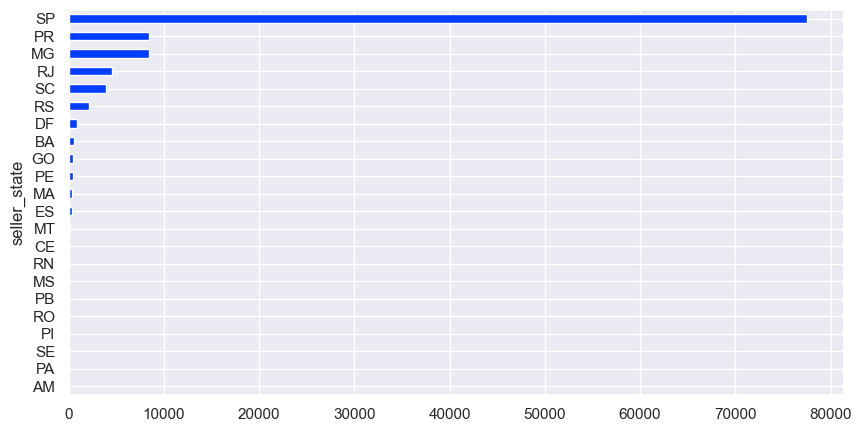

In [100]:
df['seller_state'].value_counts(ascending=True).plot(kind='barh', figsize=(10,5));

#### 1. Visão Geral de Vendas (O "Coração" do Negócio)


Crescimento Mensal: Qual é a evolução do faturamento total (GMV) e do volume de pedidos mês a mês? Existe sazonalidade?

In [ ]:

# 2. Agrupar por mês e somar o preço
# O 'to_period('M')' cria períodos como '2023-01', '2023-02', etc.
evolucao_mensal = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['price'].sum().reset_index()

# 3. Converter o período para string para o gráfico aceitar o eixo X
evolucao_mensal['order_purchase_timestamp'] = evolucao_mensal['order_purchase_timestamp'].astype(str)

# 4. Criar o gráfico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(evolucao_mensal['order_purchase_timestamp'], evolucao_mensal['price'], marker='o')

# --- FORMATAÇÃO DO EIXO Y ---

# Função que recebe o valor (x) e a posição (pos)
def format_milhoes(x, pos):
    return f'R$ {x*1e-6:,.1f}M' # 1e-6 divide por 1 milhão

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_milhoes))

# ----------------------------

plt.title('Evolução Mensal (Valores em Milhões)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108636 entries, 0 to 108635
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       108636 non-null  string        
 1   customer_id                    108636 non-null  string        
 2   order_purchase_timestamp       108636 non-null  datetime64[ns]
 3   order_approved_at              108636 non-null  datetime64[ns]
 4   order_delivered_carrier_date   108636 non-null  datetime64[ns]
 5   order_delivered_customer_date  108636 non-null  datetime64[ns]
 6   order_estimated_delivery_date  108636 non-null  datetime64[ns]
 7   customer_unique_id             108636 non-null  string        
 8   customer_zip_code_prefix       108636 non-null  string        
 9   customer_city                  108636 non-null  string        
 10  customer_state                 108636 non-null  string        
 11  

In [ ]:
# Criar coluna Dias_para_entrega_real: order_delivered_customer_date - order_purchase_timestamp

In [ ]:
# Criar coluna Dias_para_entrega_estimada: order_estimated_delivery_date - order_purchase_timestamp

In [ ]:
df["Year_purchase"] = df['order_purchase_timestamp'].dt.year #Coluna Mes da compra

In [ ]:
df["Month_purchase"] = df['order_purchase_timestamp'].dt.month #Coluna Ano da compra

In [ ]:
df[df['order_id'] == '00143d0f86d6fbd9f9b38ab440ac16f5']

In [ ]:
sns.histplot(df['order_purchase_timestamp'])

# Identifica os índices das linhas de 2016
indices_2016 = df[df['order_purchase_timestamp'].dt.year == 2016].index

# Remove os índices identificados
df = df.drop(indices_2016)

df = df[df['order_purchase_timestamp'] <= '2018-08-31']


In [ ]:
plt.figure(figsize= (12,6))
sns.histplot(df['order_purchase_timestamp'])
plt.xticks(rotation=45)
plt.show()

In [ ]:

# 2. Agrupar por mês e somar o preço
# O 'to_period('M')' cria períodos como '2023-01', '2023-02', etc.
evolucao_mensal = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['price'].sum().reset_index()

# 3. Converter o período para string para o gráfico aceitar o eixo X
evolucao_mensal['order_purchase_timestamp'] = evolucao_mensal['order_purchase_timestamp'].astype(str)

# 4. Criar o gráfico
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(evolucao_mensal['order_purchase_timestamp'], evolucao_mensal['price'], marker='o')

# --- FORMATAÇÃO DO EIXO Y ---

# Função que recebe o valor (x) e a posição (pos)
def format_milhoes(x, pos):
    return f'R$ {x*1e-6:,.1f}M' # 1e-6 divide por 1 milhão

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_milhoes))

# ----------------------------

plt.title('Evolução Mensal (Valores em Milhões)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico mostra um forte crescimento de vendas no período e um pico de alta em novembro de 20217 devido ao período de BlackFriday

In [ ]:
# 1. Agrupar por mês e calcular a soma do preço e a contagem de pedidos únicos
evolucao = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).agg({
    'price': 'sum',
    'order_id': 'nunique'
})

# 2. Calcular o ticket médio por mês
evolucao['ticket_medio'] = evolucao['price'] / evolucao['order_id']

# 3. Resetar o index para plotar
evolucao = evolucao.reset_index()
evolucao['order_purchase_timestamp'] = evolucao['order_purchase_timestamp'].astype(str)

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=evolucao, x='order_purchase_timestamp', y='ticket_medio', marker='o')

plt.title('Evolução do Ticket Médio por Mês')
plt.xticks(rotation=45)
plt.ylabel('Ticket Médio (R$)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 200)
plt.show()

In [ ]:
plt.figure(figsize = (10,20))
ordem_decrescente = df.groupby('product_category_name',observed=True)['price'].sum().sort_values(ascending=False).index
sns.barplot(data = df, y= 'product_category_name', x = 'price', errorbar = None,estimator='sum', order=ordem_decrescente)

In [ ]:
# 1. Agrupar e ordenar
pareto_df = df.groupby('product_category_name', observed = False)['price'].sum().sort_values(ascending=False).reset_index()

# 2. Calcular a porcentagem individual e a acumulada
pareto_df['percentual'] = (pareto_df['price'] / pareto_df['price'].sum()) * 100
pareto_df['acumulado'] = pareto_df['percentual'].cumsum()

# Opcional: Filtrar apenas as categorias que compõem os 80% (ou as top 20 para o gráfico não poluir)
pareto_grafico = pareto_df.head(20)

In [ ]:
# 1. Agrupar, somar e ordenar de forma decrescente
pareto_df = df.groupby('product_category_name', observed=False)['price'].sum().sort_values(ascending=False).reset_index()


# 3. Calcular o acumulado
pareto_grafico['percentual'] = (pareto_grafico['price'] / pareto_df['price'].sum()) * 100
pareto_grafico['acumulado'] = pareto_grafico['percentual'].cumsum()

pareto_grafico['product_category_name'] = pareto_grafico['product_category_name'].astype(str)

# --- PLOTAGEM ---
fig, ax1 = plt.subplots(figsize=(15, 6))

sns.barplot(
    data=pareto_grafico, 
    x='product_category_name', 
    y='price', 
    ax=ax1, 
    palette='Blues_r',
    order=pareto_grafico['product_category_name'], # <--- Força a ordem do eixo X
    hue='product_category_name', # Define que a cor vem da categoria
    legend=False                 # Remove a legenda (já que o nome está no eixo X
)

plt.xticks(rotation=45, ha='right')

# Eixo secundário (linha do acumulado)
ax2 = ax1.twinx()
# Garantimos que a linha siga os mesmos pontos do eixo X
sns.lineplot(
    data=pareto_grafico, 
    x='product_category_name', 
    y='acumulado', 
    color='red', 
    marker='D', 
    ax=ax2,
    sort=False # <--- Importante: impede que a linha tente reordenar os pontos
)

ax2.set_ylim(0, 110)
ax2.axhline(80, color='orange', linestyle='--')

plt.title('Análise de Pareto (Top 20 Categorias)')
plt.show()

In [ ]:
pareto_grafico

In [ ]:
16/73

Podemos confimar que a regra de pareto está presente nas categorias do produtos.
80% da Receita de Vendas vem do top 22% de Categoricas com maior receita de vendas acumulada.

### Onde estão os clientes? (Análise por Estado/Região).

In [ ]:
# 1. Agrupar vendas por prefixo de CEP do cliente
vendas_por_cep = df.groupby('customer_zip_code_prefix')['price'].sum().reset_index()

# 2. Carregar a base de geolocalização (comum no dataset Olist)
# Esse arquivo geralmente se chama 'olist_geolocation_dataset.csv'
geo_df = pd.read_csv(geolocation)

# Limpar duplicatas de CEP na base geo (pegar a média da lat/lng para cada prefixo)
geo_df_limpo = geo_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# Converter ambos para string para garantir a compatibilidade
vendas_por_cep['customer_zip_code_prefix'] = vendas_por_cep['customer_zip_code_prefix'].astype(str)
geo_df_limpo['geolocation_zip_code_prefix'] = geo_df_limpo['geolocation_zip_code_prefix'].astype(str)

# 3. Cruzar os dados de vendas com as coordenadas
mapa_data = pd.merge(
    vendas_por_cep, 
    geo_df_limpo, 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix'
)

In [ ]:
# Filtro básico para manter pontos dentro do território brasileiro
mapa_data = mapa_data[
    (mapa_data['geolocation_lat'] <= 5.27) & (mapa_data['geolocation_lat'] >= -33.75) &
    (mapa_data['geolocation_lng'] <= -34.73) & (mapa_data['geolocation_lng'] >= -73.98)
]

In [ ]:
import folium
from folium.plugins import HeatMap

tamanho_mapa = {"width": 500, 'height':500}
fig = folium.Figure(**tamanho_mapa)

# Criar um mapa centralizado no Brasily
mapa = folium.Map(
    location=[-15.78, -47.93], 
    zoom_start=4, 
    tiles='StadiaStamenTonerLite',
    control_scale=True
).add_to(fig)

# Preparar os dados para o HeatMap: lista de [lat, lng, peso/faturamento]
dados_heatmap = mapa_data[['geolocation_lat', 'geolocation_lng', 'price']].values.tolist()

# Adicionar a camada de calor
HeatMap(dados_heatmap, radius=15, blur=15, max_zoom=1).add_to(mapa)

# Salvar ou exibir
mapa.save('mapa_vendas_olist.html')
mapa

In [ ]:
df.info()

### Onde estão os vendedores? (Análise por Estado/Região).

In [ ]:
# 1. Agrupar vendas por prefixo de CEP do vendedor
vendedor_por_cep = df.groupby('seller_zip_code_prefix')['price'].sum().reset_index()

# 3. Cruzar os dados de vendas com as coordenadas
mapa_data_vendedor = pd.merge(
    vendedor_por_cep, 
    geo_df_limpo, 
    left_on='seller_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix'
)

In [ ]:
# Filtro básico para manter pontos dentro do território brasileiro
mapa_data_vendedor = mapa_data_vendedor[
    (mapa_data_vendedor['geolocation_lat'] <= 5.27) & (mapa_data_vendedor['geolocation_lat'] >= -33.75) &
    (mapa_data_vendedor['geolocation_lng'] <= -34.73) & (mapa_data_vendedor['geolocation_lng'] >= -73.98)
]

In [ ]:
import folium
from folium.plugins import HeatMap

# Criar um mapa centralizado no Brasily
mapa_vendedor = folium.Map(location=[-15.78, -47.93], zoom_start=4, tiles='cartodbpositron')

# Preparar os dados para o HeatMap: lista de [lat, lng, peso/faturamento]
dados_heatmap = mapa_data_vendedor[['geolocation_lat', 'geolocation_lng', 'price']].values.tolist()

# Adicionar a camada de calor
HeatMap(dados_heatmap, radius=20, blur=20, max_zoom=1).add_to(mapa_vendedor)

# Salvar ou exibir
mapa_vendedor.save('mapa_vendas_olist.html')

In [ ]:
mapa_vendedor

In [ ]:
df.head(5)